In [1]:
# ─────────────────────────────────────────────────────────────
#  Configuración inicial - Instalación de dependencias
# ─────────────────────────────────────────────────────────────
# !pip install plantuml requests ipython -q
# Ignore este código sólo se corre al inicio para conectar con plantuml y renderizar las imágenes dentro de este documento
# pero como puede darse cuenta al leer, las imágenes ya están renderizadas

import os
import tempfile
from pathlib import Path
from IPython.display import Image, display, Markdown, Code

# ── Renderizador de diagramas PlantUML ──
try:
    from plantuml import PlantUML
    PLANTUML_SERVER = PlantUML(url='http://www.plantuml.com/plantuml/img/')
    _plantuml_available = True
except ImportError:
    _plantuml_available = False

def render_plantuml(plantuml_code, width=800):
    # Renderiza código PlantUML y muestra la imagen. Si no hay conexión al servidor, muestra el código fuente. #
    #==========================================================================================================#
    
    full_code = plantuml_code.strip()
    if not full_code.startswith('@startuml'):
        full_code = '@startuml\n' + full_code
    if not full_code.rstrip().endswith('@enduml'):
        full_code = full_code.rstrip() + '\n@enduml'

    if _plantuml_available:
        try:
            img_data = PLANTUML_SERVER.processes(full_code)
            display(Image(data=img_data, width=width))
            return
        except Exception:
            pass

    # Fallback: mostrar código fuente
    print('[WARN] No se pudo renderizar el diagrama (sin conexion al servidor PlantUML).')
    print('Código fuente:')
    print('```plantuml')
    print(full_code)
    print('```')

def render_plantuml_from_file(puml_path, width=800):
    #Lee un archivo .puml y renderiza el diagrama.#
    #=============================================#
    try:
        with open(puml_path, 'r', encoding='utf-8') as f:
            code = f.read()
        render_plantuml(code, width)
    except FileNotFoundError:
        print(f'Archivo no encontrado: {puml_path}')

print('Configuracion completada. Los diagramas PlantUML se renderizaran en linea.')


Configuracion completada. Los diagramas PlantUML se renderizaran en linea.


# 1. ¿Qué es un diagrama de estados? El ciclo de vida de un objeto

En los temas anteriores, hemos visto cómo los casos de uso nos dicen *qué* hace el sistema, los diagramas de clases nos muestran *quién* lo compone, y los diagramas de secuencia revelan *cómo* colaboran los objetos para cumplir un escenario. Pero hay una pregunta que todavía no hemos respondido con suficiente profundidad: **¿cómo se comporta un objeto a lo largo del tiempo, más allá de una única interacción?** ¿Qué le sucede a un `Pedido` desde que nace hasta que se cierra? ¿Por qué estados atraviesa? ¿Qué eventos provocan esos cambios? Aquí es donde entra en escena el diagrama de estados, una herramienta que, como Project Manager, considero indispensable para entender y documentar el ciclo de vida de las entidades más importantes del sistema.

## 1.1. Definición: La máquina de estados de una instancia

Un diagrama de estados es un artefacto UML que describe **todos los estados posibles por los que puede pasar una instancia de una clase** durante su existencia, y cómo esa instancia transita de un estado a otro en respuesta a **eventos** que ocurren en el sistema. A diferencia de los diagramas de secuencia, que muestran una coreografía específica entre múltiples objetos para un escenario concreto, el diagrama de estados se centra en **un único objeto** y en todos los caminos que su vida puede tomar.

Como docente y como gestor, suelo ilustrar el concepto con una analogía sencilla: si el diagrama de clases es la foto de familia (la estructura), y el diagrama de secuencia es una escena de una película (un momento de interacción), el diagrama de estados es el mapa del viaje de un personaje, mostrando todas las ciudades que visita, qué le hace moverse de una a otra y qué equipaje lleva en cada etapa.

En UML, cada estado representa una situación en la vida del objeto durante la cual se cumple una condición, se realiza una actividad o se espera un evento. Las transiciones, dibujadas como flechas entre estados, se etiquetan con el evento que las dispara, y opcionalmente con una condición de guarda y una acción. La herramienta PlantUML, que ya conocemos, nos permite dibujar estos diagramas con una sintaxis muy natural, que iré mencionando a lo largo del tema.

## 1.2. Propósito: Modelar el comportamiento interno de un objeto a lo largo del tiempo

¿Por qué necesitamos un diagrama de estados si ya tenemos casos de uso y diagramas de secuencia? La respuesta es que cada uno captura una dimensión diferente de la dinámica del sistema:

- **Los casos de uso** describen secuencias de interacción entre actores y el sistema en su conjunto. Nos cuentan la historia desde fuera.
- **Los diagramas de secuencia** descomponen un caso de uso en la colaboración de varios objetos, mostrando el orden de los mensajes. Son como radiografías de una jugada.
- **El diagrama de estados** se sumerge en **un solo objeto** y modela cómo responde ante todos los eventos que recibe a lo largo del tiempo, independientemente de quién los envíe. Es el historial médico de un objeto: cómo evoluciona su "salud" interna.

Esta perspectiva es crucial para clases cuyo ciclo de vida es complejo y está gobernado por reglas de negocio estrictas. Pensemos en un `Pedido` en un sistema de comercio electrónico. No basta con saber que el pedido tiene un atributo `estado` de tipo `String`. Necesitamos entender qué valores puede tomar ese atributo, en qué orden, y qué fuerzas externas o internas provocan el cambio. ¿Puede un pedido pasar directamente de "Entregado" a "Cancelado"? Probablemente no, y el diagrama de estados nos ayuda a visualizar y validar esas restricciones.

Además, el diagrama de estados revela **comportamiento que no es evidente en un diagrama de secuencia aislado**. Un diagrama de secuencia del flujo básico de "Realizar Pedido" solo mostrará la ruta feliz: creación, confirmación, pago. Pero el `Pedido` puede ser cancelado en varios momentos, puede requerir una verificación manual si el importe es elevado, o puede rebotar si el pago falla. El diagrama de estados unifica todos esos posibles escenarios en una sola vista, facilitando la detección de estados no contemplados, transiciones imposibles o acciones faltantes.

## 1.3. Conexión con otros diagramas: la sinergia de los modelos UML

Una de las habilidades más importantes que pueden desarrollar como ingenieros de software es la de leer los distintos diagramas UML no como piezas aisladas, sino como partes de un todo coherente. El diagrama de estados no es una isla; se conecta directamente con los casos de uso, el diagrama de clases y los diagramas de secuencia. Exploremos estas relaciones, que son las que realmente dan valor al modelo.

### 1.3.1. Casos de Uso: El origen de los eventos

Cada transición en un diagrama de estados ocurre, en última instancia, porque un actor ejecuta un caso de uso (o porque se cumple una condición temporal, modelada como un evento de sistema). Si en el diagrama de estados del `Pedido` tenemos una transición de "En Creación" a "Confirmado" etiquetada con `confirmarPedido()`, esa transición existe porque el caso de uso "Realizar Pedido" incluye un paso en el que el cliente confirma el pedido.

En la gestión de proyectos, siempre exijo que cada evento en un diagrama de estados sea trazable hasta un caso de uso. Si encontramos una transición cuyo evento no aparece en ningún caso de uso, estamos ante un problema: o bien nos falta un caso de uso (requisito no documentado), o bien el evento es un artificio técnico que debería ocultarse (por ejemplo, un evento interno de temporizador que, en realidad, responde a un requisito temporal que sí debe estar documentado). Esta trazabilidad nos asegura que el diseño no se desvía de lo que el negocio necesita.

### 1.3.2. Diagrama de Clases: El dueño del estado

Un diagrama de estados siempre está asociado a una única clase del diagrama de clases. No modela el sistema completo, sino el ciclo de vida de las instancias de una clase específica. Esta vinculación tiene implicaciones prácticas muy concretas:

- **Los estados son valores de un atributo**: Si el `Pedido` tiene un estado "Pagado", en la clase `Pedido` debe existir un atributo (por ejemplo, `estado: String` o, mejor aún, un `EstadoPedido` de tipo enumerado) que refleje ese valor. El diagrama de estados nos ayuda a decidir qué atributos necesita la clase y qué valores legales puede tomar.
- **Los eventos son métodos**: Cada evento en una transición debería corresponder a un método en la clase del objeto, o a un mensaje que el objeto recibe y que dispara un cambio interno. Por ejemplo, el evento `pagar()` está asociado a un método `pagar()` en la clase `Pedido`, o quizás a un mensaje recibido de un servicio de pago.
- **Las acciones son implementaciones**: Cuando una transición incluye una acción (por ejemplo, `entrada / enviarCorreoConfirmación()`), ésa acción debe ser un método real de la clase, o una colaboración con otro objeto. El diagrama de estados, por tanto, guía la definición de métodos en la clase.

En mis proyectos, cuando un equipo define un diagrama de estados para una entidad, automáticamente revisamos el diagrama de clases para asegurarnos de que el atributo de estado existe, de que los métodos de evento están declarados, y de que las acciones están respaldadas por la lógica adecuada. Si descubrimos un método que no se había previsto, lo añadimos al modelo de clases; si un atributo de estado es demasiado genérico, lo refinamos. Esta bidireccionalidad es lo que mantiene viva la documentación.

### 1.3.3. Diagrama de Secuencia: El contexto del evento

Mientras que el diagrama de estados muestra *cómo* reacciona un objeto a un evento, el diagrama de secuencia muestra *quién* envió ese evento y *cómo* la reacción del objeto afecta al resto del sistema. Son dos vistas complementarias del mismo evento.

Supongamos que el diagrama de estados del `Pedido` tiene una transición de "Pendiente de Pago" a "Pagado" disparada por el evento `pagoConfirmado()`. Si consultamos el diagrama de secuencia del flujo básico de "Realizar Pedido", veremos que ese evento no es espontáneo: es el `ServicioPago` el que, tras procesar la transacción, retorna una confirmación que el `ControladorPedido` traduce en una llamada `pagar()` al `Pedido`. El diagrama de secuencia nos da el contexto operacional: qué otros objetos están involucrados, en qué orden suceden las cosas, y qué datos se pasan.

Esta conexión es crucial para la validación. Si en el diagrama de estados veo un evento `cancelar()`, debo encontrar al menos un diagrama de secuencia (o fragmento combinado `alt` en uno existente) donde el `Pedido` reciba ese mensaje. Si no existe tal diagrama, el agujero en el modelado es evidente: alguien ha asumido una funcionalidad que no está documentada en interacciones concretas. Como líder de proyecto, utilizo esta comprobación cruzada para garantizar que el diseño es completo y consistente.

## 1.4. Valor para el Project Manager: más allá del dibujo

Desde la trinchera de la gestión, el diagrama de estados me proporciona un control de calidad que valoro profundamente. Al forzar al equipo a modelar el ciclo de vida de las entidades críticas, consigo:

- **Eliminar ambigüedades y "estados imposibles"**: El diagrama de estados hace explícito qué transiciones son legales y cuáles no. Si un desarrollador intenta pasar un pedido de "Entregado" a "En Creación", la documentación (y el código, si está bien diseñado) lo impedirá. Esto evita bugs muy difíciles de rastrear.
- **Definir el vocabulario del dominio**: Los estados ("Pendiente", "Confirmado", "Pagado", "Enviado", "Cancelado", "Devuelto") se convierten en parte del lenguaje ubicuo del proyecto. Todo el equipo, incluyendo a los stakeholders, habla el mismo idioma cuando discute por dónde va un pedido.
- **Detectar requisitos ocultos**: A menudo, al dibujar el diagrama de estados, el equipo se pregunta: "¿Y qué pasa si el cliente se arrepiente después de pagar pero antes de que enviemos?". Esa pregunta puede revelar la necesidad de un nuevo estado ("Devuelto") o de un caso de uso adicional ("Solicitar Devolución"), que de otra forma se descubriría durante el desarrollo o, peor, en producción.
- **Facilitar la estimación y la planificación**: Una clase con muchos estados y transiciones complejas requerirá más esfuerzo de implementación, pruebas y, sobre todo, manejo de errores. Como PM, puedo usar la complejidad del diagrama de estados como un insumo para refinar estimaciones y asignar recursos adecuados.
- **Mejorar las pruebas**: Los testers pueden derivar escenarios de prueba directamente del diagrama de estados: probar cada transición, cada condición de guarda, cada acción, y asegurarse de que las transiciones prohibidas realmente no ocurren. Esto aumenta la cobertura de pruebas y reduce el riesgo de defectos en producción.

## 1.5. Un vistazo hacia adelante

En los próximos temas, profundizaremos en los elementos que componen un diagrama de estados: los estados simples y compuestos, las transiciones con eventos, condiciones y acciones, los pseudoestados como el inicial y el final, y las estructuras de concurrencia. También abordaremos directamente la notación PlantUML para dibujar estos diagramas, y cómo, mediante `skinparam` y `style`, podemos adaptar su apariencia para que comuniquen con la mayor claridad posible. Pero la base conceptual ya la tienen: el diagrama de estados es la carta de navegación de un objeto, y como toda buena carta, debe estar sincronizada con el resto de mapas (casos de uso, clases y secuencia) si queremos llegar a buen puerto.

# 2. Elementos fundamentales del diagrama de estados

En el tema anterior establecimos que un diagrama de estados describe el ciclo de vida de un objeto, mostrando los estados por los que pasa y cómo transita entre ellos. Ahora vamos a desmenuzar con precisión quirúrgica los ladrillos que componen ese mapa de comportamiento: qué es exactamente un estado, qué información contiene, cómo se modela una transición y los distintos tipos de pseudoestados que nos permiten controlar el flujo de la máquina de estados. Desde la dirección del proyecto, considero que la comprensión profunda de estos elementos es lo que distingue a un diseñador que simplemente “dibuja cajitas” de otro que realmente entiende y puede predecir cómo se comportará una entidad crítica del sistema en cualquier circunstancia.

## 2.1. El Estado: Mucho más que un nombre

Un estado es una situación o condición en la vida de un objeto durante la cual:
- Se satisface una **condición** (por ejemplo, el pedido ha sido confirmado por el cliente).
- Se realiza una **actividad** de manera continua (el sistema está “esperando confirmación de pago”).
- O se está a la **espera** de que ocurra un evento externo (el envío está “en tránsito” esperando la entrega del transportista).

Lejos de ser una simple etiqueta, un estado encapsula todo lo que el objeto “hace” o “es” mientras se encuentra en él. En UML, un estado se representa gráficamente como un rectángulo con las esquinas redondeadas. En su interior, además del nombre del estado, podemos incluir **comportamientos internos** predefinidos que se ejecutan al entrar, durante o al salir del estado. Estas acciones se denotan con las palabras reservadas `entry`, `exit` y `do`:

- `entry / acción`: lo que ocurre al entrar al estado.
- `exit / acción`: lo que ocurre al salir del estado.
- `do / actividad`: una actividad continua que se ejecuta mientras el objeto permanece en el estado.

PlantUML nos permite definir estos comportamientos con una sintaxis muy clara, tanto dentro de la llave de un estado compuesto como con la notación abreviada de dos puntos. Por ejemplo, un pedido en estado “Confirmado” podría tener una actividad `do / notificarCliente()` que se ejecuta mientras el pedido está confirmado pero aún no se ha pagado.

Veamos un ejemplo simple en notación PlantUML. Mostraré cómo declarar un estado con acciones internas:


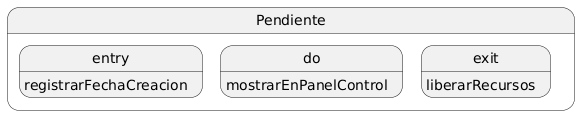

In [3]:
# Diagrama PlantUML
plantuml_code = '''@startuml
state Pendiente {
  entry : registrarFechaCreacion
  do : mostrarEnPanelControl
  exit : liberarRecursos
}
@enduml'''

render_plantuml(plantuml_code)


Este diagrama muestra el estado `Pendiente` de un objeto, con una acción que se ejecuta al entrar (`entry`), una actividad continua (`do`) y una acción al salir (`exit`). Todo esto se reflejará posteriormente en el diseño detallado de la clase correspondiente.

## 2.2. La Transición: El viaje entre estados

Una transición es una flecha dirigida que conecta un estado origen con un estado destino. Representa el cambio de estado que sufre un objeto cuando ocurre un **evento** y, opcionalmente, se cumple una **condición** (o guarda) y se ejecuta una **acción**. La sintaxis general en UML es:

`Evento [Condición] / Acción`

- **Evento**: es el disparador que provoca el cambio de estado. Suelen ser llamadas a métodos del objeto (por ejemplo, `confirmar()`) o señales de otros objetos (por ejemplo, `pagoConfirmado`). Cada evento debe corresponderse con un método definido en la clase del diagrama de clases, o con un mensaje que el objeto recibe en algún diagrama de secuencia.
- **Condición (guarda)**: una expresión booleana opcional que debe ser verdadera para que la transición se produzca. Por ejemplo, `[stockSuficiente]` en una transición que decrementa el inventario. Si la condición no se cumple, el evento no produce ningún cambio de estado.
- **Acción**: una operación que se ejecuta justo en el momento de la transición. Puede ser una llamada a un método, el envío de un evento a otro objeto o el cambio de un atributo.

En PlantUML, las transiciones se representan con flechas entre estados, y la etiqueta se coloca directamente sobre la línea de la flecha. Siguiendo con el ejemplo del pedido:


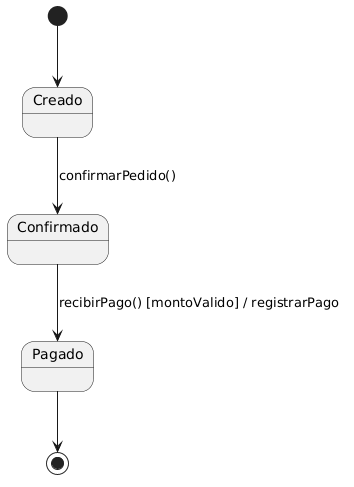

In [4]:
# Diagrama PlantUML
plantuml_code = '''@startuml
[*] --> Creado
Creado --> Confirmado : confirmarPedido()
Confirmado --> Pagado : recibirPago() [montoValido] / registrarPago
Pagado --> [*]
@enduml'''

render_plantuml(plantuml_code)


En este fragmento, vemos cómo el evento `confirmarPedido()` provoca la transición de `Creado` a `Confirmado`. La transición de `Confirmado` a `Pagado` solo ocurre si, además del evento `recibirPago()`, la guarda `montoValido` es verdadera, y en ese momento se ejecuta la acción `registrarPago`. Finalmente, un estado final indica que el ciclo de vida del objeto ha terminado.

## 2.3. Pseudoestados Inicial y Final: El origen y el destino

Los pseudoestados son elementos especiales que no representan estados reales del objeto, sino que controlan el flujo del diagrama. Los dos más importantes son el estado inicial y el estado final.

- **Estado Inicial**: se representa como un círculo relleno. Indica el punto de partida de la máquina de estados, es decir, dónde nace el objeto. Todo diagrama de estados debe tener un único estado inicial, del que sale una transición sin evento (o con un evento de creación) hacia el primer estado real. En PlantUML se escribe como `[*]` y es el origen de la primera flecha.
- **Estado Final**: se representa como un círculo rodeado por un borde y con un punto interior (como una diana). Indica que el objeto ha completado su ciclo de vida y debe ser destruido (o al menos dejar de procesar eventos). Una máquina de estados puede tener varios estados finales si el objeto puede terminar de diferentes maneras, pero cada camino debe conducir a uno. En PlantUML también se denota con `[*]`, pero como destino de una flecha.

En el ejemplo anterior, vimos cómo `[*] --> Creado` marca el nacimiento del pedido, y `Pagado --> [*]` su finalización exitosa. La simbología es sencilla pero poderosa, y su uso correcto evita que el objeto quede “huérfano” o en un estado limbo que nadie había previsto.

## 2.4. Estados Compuestos: La jerarquía del comportamiento

Cuando el comportamiento asociado a un estado es complejo, UML permite **anidar** una máquina de estados completa dentro de otro estado. Es lo que se denomina **estado compuesto** (o submáquina). Al entrar en el estado compuesto, se activa su estado inicial interno, y al salir se abandonan todos sus subestados. Esto permite descomponer un estado de alto nivel en pasos más finos sin perder la visión global.

En PlantUML, un estado compuesto se define con la palabra reservada `state` seguida del nombre y un bloque de llaves `{}` que contiene la submáquina completa. Por ejemplo, un pedido en estado “Activo” podría descomponerse en “En Creación”, “Confirmado” y “Pagado”:


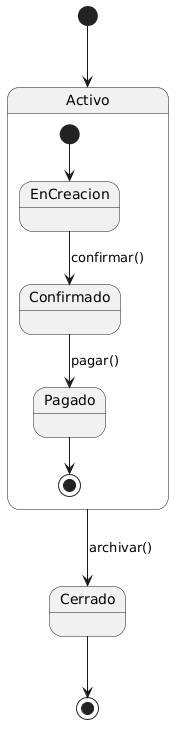

In [5]:
# Diagrama PlantUML
plantuml_code = '''@startuml
[*] --> Activo
state Activo {
  [*] --> EnCreacion
  EnCreacion --> Confirmado : confirmar()
  Confirmado --> Pagado : pagar()
  Pagado --> [*]
}
Activo --> Cerrado : archivar()
Cerrado --> [*]
@enduml'''

render_plantuml(plantuml_code)


En este diagrama, `Activo` es un estado compuesto que contiene a su vez otros tres estados y sus transiciones. El objeto está en `Activo` mientras está en cualquiera de sus subestados. La transición `Activo --> Cerrado` es aplicable desde cualquier subestado interno, lo que evita tener que dibujar flechas desde cada uno de ellos.

## 2.5. Estados Concurrentes: Múltiples dimensiones a la vez

Algunos objetos pueden tener comportamientos simultáneos que evolucionan de forma independiente. Por ejemplo, mientras un pedido está siendo procesado, puede estar a la vez en un estado de “Facturación” y en un estado de “Preparación de Envío”, cada uno con sus propias fases. UML modela esta situación con **estados concurrentes** (o regiones ortogonales), que se representan dividiendo el estado compuesto en zonas separadas por líneas discontinuas.

En PlantUML, la forma más común de definir concurrencia es usando los símbolos `--` (separación horizontal) o `||` (separación vertical) dentro de un estado compuesto. Cada región definida de esta manera contiene una submáquina independiente, y el objeto estará en un estado de cada región simultáneamente. Por ejemplo:


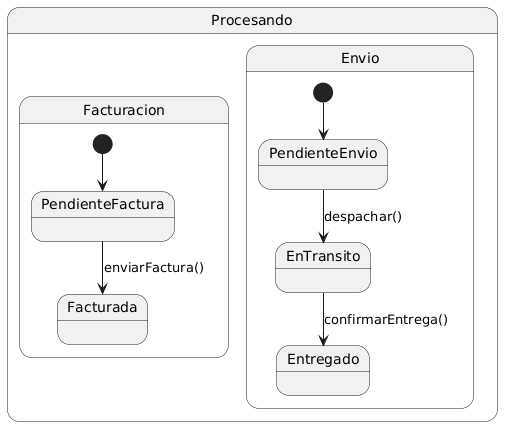

In [8]:
# Diagrama PlantUML
plantuml_code = '''@startuml
state Procesando {
  state Facturacion {
    [*] --> PendienteFactura
    PendienteFactura --> Facturada : enviarFactura()
  }
  state Envio {
    [*] --> PendienteEnvio
    PendienteEnvio --> EnTransito : despachar()
    EnTransito --> Entregado : confirmarEntrega()
  }
}
@enduml'''

render_plantuml(plantuml_code)


Aquí, el estado `Procesando` contiene dos regiones separadas por `--`. El objeto estará, por ejemplo, en `PendienteFactura` y `PendienteEnvio` a la vez, y cada región evolucionará según sus propios eventos. La salida del estado compuesto suele ocurrir cuando todas las regiones activas han alcanzado un estado final, o cuando una transición de grupo las interrumpe.

## 2.6. Puntos de Elección y Bifurcación/Unión

Para controlar el flujo de transiciones sin necesidad de estados ficticios, UML proporciona varios pseudoestados adicionales:

- **Punto de Elección (`<<choice>>`)**: representa una decisión dinámica dentro de una transición. Permite evaluar condiciones tras un evento y enrutar a diferentes estados de destino, todo ello sin ejecutar acciones hasta que se ha elegido el camino. En PlantUML, se dibuja como un diamante con el estereotipo `<<choice>>`.
- **Bifurcación (`<<fork>>`) y Unión (`<<join>>`)**: se utilizan en combinación con estados concurrentes. Una bifurcación divide una transición en varios flujos concurrentes que entran en distintas regiones de un estado compuesto. Una unión sincroniza varios flujos concurrentes en un solo flujo, esperando a que todos hayan llegado antes de continuar. En PlantUML, se escriben con los estereotipos `<<fork>>` y `<<join>>` sobre el pseudoestado correspondiente.

Un ejemplo con un punto de elección:


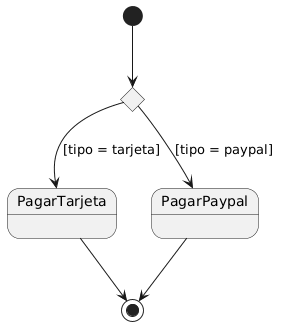

In [9]:
# Diagrama PlantUML
plantuml_code = '''@startuml
state ElegirTipoPago <<choice>>
[*] --> ElegirTipoPago
ElegirTipoPago --> PagarTarjeta : [tipo = tarjeta]
ElegirTipoPago --> PagarPaypal : [tipo = paypal]
PagarTarjeta --> [*]
PagarPaypal --> [*]
@enduml'''

render_plantuml(plantuml_code)


Observen cómo el diamante etiquetado como `<<choice>>` toma la decisión basada en el valor de la condición `tipo`. Las acciones asociadas a cada rama se ejecutarán después de elegir el camino.

## 2.7. Integración con el resto del modelo

Cada uno de estos elementos debe mantener una coherencia absoluta con el modelo de clases y los diagramas de secuencia. Como responsable del proyecto, insisto en la siguiente verificación cruzada:

- Los nombres de los eventos en las transiciones deben coincidir con mensajes que el objeto recibe en los diagramas de secuencia. Si el evento `confirmarPedido()` aparece en el diagrama de estados, en algún diagrama de secuencia debe verse al objeto `Pedido` recibiendo ese mensaje desde un controlador u otro objeto.
- Los estados, en la mayoría de los casos, deben corresponderse con valores de un atributo de la clase, generalmente un atributo `estado` de tipo `String` o `Enum`. Esto asegura que el estado se pueda consultar y persistir.
- Las acciones (`entry`, `exit`, `do`) y las acciones de transición deben ser métodos reales en la clase del objeto, o colaboraciones con otras clases que aparezcan en el diagrama de clases. Si se menciona una acción `registrarPago`, en el diagrama de clases debe existir un método asociado a la clase `Pedido` o a un servicio que el `Pedido` invoca.

Con estos fundamentos sólidamente asentados, en el próximo tema abordaremos el proceso de **derivación de estados** a partir del análisis de los casos de uso y de los diagramas de secuencia, para que todo el modelo esté perfectamente conectado y justificado por las necesidades del sistema.

# 3. Derivando estados desde la arquitectura del sistema

Hemos estudiado la teoría de los diagramas de estado y sus elementos. Ahora abordaremos el proceso inverso: cómo, a partir de los artefactos que ya tenemos —casos de uso, diagramas de clases y diagramas de secuencia—, podemos extraer y construir rigurosamente la máquina de estados de una entidad. Porque un diagrama de estado no es un gráfico aislado que se dibuja por capricho. Es la destilación del comportamiento temporal de una clase, y su construcción debe estar guiada por las necesidades funcionales y la arquitectura del sistema. En el rol de líder del proyecto, este proceso de derivación me permite auditar que el diseño es completo y que no hay "agujeros" funcionales.

## 3.1. Identificación de la clase candidata: no todo merece un estado

El primer error que cometen los equipos es querer dibujar un diagrama de estado para cada clase del sistema. Esto es una pérdida de tiempo monumental. Modelar el ciclo de vida de una clase de utilidad, un DTO (Data Transfer Object) o un servicio sin estado no aporta valor. Un diagrama de estado solo se justifica para lo que denominamos **entidades de negocio críticas**, aquellas cuyo comportamiento temporal es complejo y está gobernado por reglas de negocio estrictas.

¿Cómo identificamos estas clases? Durante las reuniones de análisis, cuando un stakeholder dice frases como “un pedido puede estar pendiente, luego se confirma, se paga, se envía...”, está describiendo el ciclo de vida de `Pedido`. Si un analista funcional menciona que “una solicitud de vacaciones la aprueba el jefe, pero si es de más de diez días también Recursos Humanos”, la clase `SolicitudVacaciones` es una firme candidata. 

Otros ejemplos clásicos incluyen `Envío` (con estados como “En preparación”, “En tránsito”, “Entregado”, “Extraviado”), `Usuario` o `Cuenta` (con estados relacionados con la verificación, activación y suspensión), o cualquier otra clase que tenga un atributo denominado `estado`, `fase` o `situación`.

La regla de oro es: si una clase tiene un atributo que solo puede tomar un conjunto finito de valores, y el cambio de un valor a otro está gobernado por eventos, esa clase necesita un diagrama de estado. PlantUML nos ayuda a documentar esta decisión con un simple comentario al inicio del archivo: `' Diagrama de estados para la clase Pedido.`

## 3.2. Rastreo de eventos: inspeccionando los diagramas de secuencia

Una vez seleccionada la clase, la pregunta inmediata es: ¿qué eventos provocan que cambie de estado? La respuesta no la encontramos en el vacío, sino en los **diagramas de secuencia** que ya hemos construido (o que construiremos) para los casos de uso.

Como vimos en el bloque de diagramas de secuencia, cada mensaje que una instancia de nuestra clase candidata recibe es un potencial **evento disparador**. Debemos rastrear todos los diagramas de secuencia donde aparezca la clase y anotar los mensajes entrantes. Por ejemplo, para la clase `Pedido`, inspeccionamos los diagramas de secuencia de casos de uso como “Realizar Pedido”, “Cancelar Pedido”, “Procesar Pago”, “Gestionar Envío”, etc.

El procedimiento es casi mecánico:

1. Recopilar todos los diagramas de secuencia en los que la clase aparece como línea de vida.
2. Listar todos los mensajes que la clase recibe en esos diagramas, sin importar quién los envía.
3. Esos mensajes se convierten en los candidatos a eventos de transición: `confirmar()`, `pagar()`, `cancelar()`, `enviar()`, `entregar()`, `devolver()`, etc.

Este paso tiene un valor incalculable para la gestión del proyecto. Si al revisar encontramos un evento en el diagrama de estados que no aparece en ningún diagrama de secuencia, hemos detectado un requisito no implementado. Si, por el contrario, un mensaje importante del diagrama de secuencia no provoca un cambio de estado, quizás hemos pasado por alto una regla de negocio. Esta validación cruzada es, para mí, una de las auditorías de calidad más rentables que existen.

## 3.3. Definición de estados y atributos: del mensaje al atributo

Con la lista de eventos, el siguiente paso es definir los estados. La manera más rigurosa de hacerlo es pensar en los estados como los valores que el atributo `estado` de la clase puede tomar entre evento y evento. En el diagrama de clases, esta columna se modela como un atributo (por ejemplo, `estado: String` o `estado: EnumEstadoPedido`), y cada estado del diagrama se corresponde con uno de sus posibles valores.

Los nombres de los estados deben reflejar una situación estable y significativa para el negocio. No son acciones (“Pagando”) sino condiciones (“Pagado”). No son verbos, sino participios o adjetivos que indican que el objeto está *en* esa situación. Podemos identificarlos preguntándonos: “Después de que ocurra el evento X, ¿cómo describiría el analista de negocio la situación del objeto?”. La respuesta es el nombre del estado.

Además de los estados, el diagrama de estados suele incluir **acciones** asociadas a las transiciones (por ejemplo, `enviarCorreoConfirmacion()`). Estas acciones deben estar respaldadas por métodos en la clase o por colaboraciones con otros objetos. Si una acción implica notificar a otro sistema, en el diagrama de clases debe existir una dependencia hacia la clase que representa ese servicio. Todo debe cuadrar.

En PlantUML, podemos empezar a prototipar el diagrama de forma muy sencilla, declarando los estados y las transiciones con los eventos encontrados, y luego enriqueciéndolo con condiciones y acciones. El código PlantUML se convierte en la especificación ejecutable del ciclo de vida de la clase. Y como todo en PlantUML, se versiona y evoluciona con el proyecto.

# 4. Notación PlantUML para diagramas de estados

Hemos llegado al punto en que la teoría del modelado de estados debe materializarse en una herramienta concreta que el equipo pueda usar, versionar y compartir. La guía de referencia de PlantUML (páginas 210 a 231) nos proporciona una notación textual rica y expresiva para diagramas de estados. En este tema, recorreremos esa notación de manera sistemática, desde la declaración más básica hasta las construcciones avanzadas, vinculando cada elemento sintáctico con los conceptos de diseño que hemos discutido en los temas anteriores. En mi experiencia dirigiendo proyectos, valoro que una notación sea clara, concisa y mantenible; PlantUML cumple estos requisitos con creces, y mi objetivo es que al finalizar este tema ustedes dominen su uso para cualquier entidad de negocio que necesiten modelar.

## 4.1. La declaración básica: estados y transiciones simples

La esencia de un diagrama de estados en PlantUML se construye con apenas un par de reglas sintácticas. La declaración de un estado es simplemente escribir su nombre, y la transición se define con una flecha `-->`. El estado inicial y el final se representan ambos con el símbolo `[*]`, pero con una diferencia fundamental: cuando `[*]` aparece como origen de una flecha, es el estado inicial; cuando aparece como destino, es el estado final.

La sintaxis mínima para un diagrama de estados se compone de estos elementos:


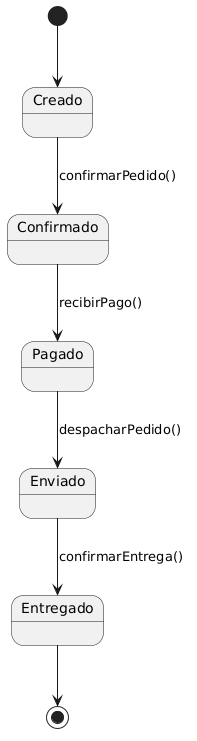

In [10]:
# Diagrama PlantUML
plantuml_code = '''@startuml
' Declaración básica: flujo de vida de un Pedido
[*] --> Creado
Creado --> Confirmado : confirmarPedido()
Confirmado --> Pagado : recibirPago()
Pagado --> Enviado : despacharPedido()
Enviado --> Entregado : confirmarEntrega()
Entregado --> [*]
@enduml'''

render_plantuml(plantuml_code)


En este ejemplo, cada línea expresa una transición. La etiqueta después de los dos puntos representa el evento que dispara el cambio. Observen la simplicidad: no hemos necesitado declarar previamente los estados; PlantUML los reconoce automáticamente al aparecer en las flechas. Sin embargo, yo recomiendo declararlos explícitamente con la palabra `state` cuando el diagrama crece, para mantener el control y poder añadir detalles internos más adelante.

La guía de PlantUML (página 210) también nos muestra que podemos cambiar la dirección de las flechas con `-up->`, `-down->`, `-left->` y `-right->`, lo que resulta útil para diagramas con muchos estados y transiciones que podrían solaparse. No obstante, en la mayoría de los casos, la disposición automática de Graphviz (el motor de diseño) produce resultados muy aceptables sin necesidad de ajustes manuales.

## 4.2. Estados con comportamiento interno: entry, exit y do

Un estado no es solo una palabra. Como vimos en el tema 2, un estado puede encapsular acciones que se ejecutan al entrar, al salir o durante la permanencia en él. PlantUML ofrece varias formas de expresar estas acciones internas, y la elección depende de cuánto detalle necesitemos mostrar.

La primera forma es la notación compacta con dos puntos, adecuada para estados simples:


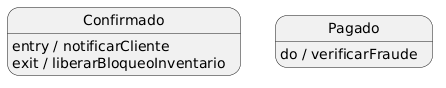

In [11]:
# Diagrama PlantUML
plantuml_code = '''@startuml
state Confirmado : entry / notificarCliente
state Confirmado : exit / liberarBloqueoInventario
state Pagado : do / verificarFraude
@enduml'''

render_plantuml(plantuml_code)


Cada línea añade una acción interna al estado. La palabra reservada `entry` indica que la acción se ejecuta al entrar en el estado; `exit`, al salir; `do`, mientras se permanece en él. Esta notación es clara pero dispersa, ya que cada acción va en una línea separada.

Para estados con varias acciones internas, o cuando queremos agrupar visualmente toda la información del estado, la sintaxis de bloque con llaves es más adecuada:


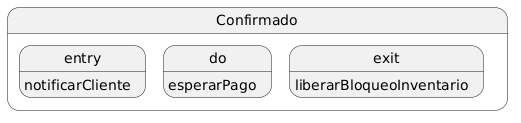

In [13]:
# Diagrama PlantUML
plantuml_code = '''@startuml
state Confirmado {
  entry : notificarCliente
  do : esperarPago
  exit : liberarBloqueoInventario
}
@enduml'''

render_plantuml(plantuml_code)


Este formato, que la guía detalla en las páginas 211-212, es mi preferido para la documentación formal, porque encapsula toda la lógica del estado en un solo lugar y facilita la lectura.

## 4.3. Estados compuestos y submáquinas: la jerarquía en acción

Como vimos, un estado puede contener una máquina de estados completa. En PlantUML, esto se logra colocando el bloque de estados internos dentro de las llaves del estado padre. La sintaxis es idéntica a la del nivel raíz, incluyendo su propio estado inicial y final.

Retomemos el ejemplo del estado `Activo` que vimos en la sección 2.4. Allí se mostraba cómo un pedido cuyo ciclo de vida se descompone en `EnCreacion`, `Confirmado` y `Pagado` se modela con un estado compuesto. En PlantUML, esa descomposición se escribe con la sintaxis de llaves que acabamos de describir, y la transición `Activo --> Cerrado` desde el nivel superior evita repetir flechas desde cada subestado.

La guía de PlantUML (páginas 211-213) también documenta la posibilidad de tener subestados anidados, y de que un estado compuesto herede las transiciones de su padre. Esta notación es perfectamente compatible con los ejemplos que hemos ido construyendo.

## 4.4. Concurrencia: modelando dimensiones paralelas

Los objetos pueden tener comportamientos que evolucionan de forma independiente. PlantUML ofrece dos notaciones para dividir un estado compuesto en regiones concurrentes: el separador horizontal `--` y el separador vertical `||`. Ambos se colocan dentro de las llaves del estado compuesto y delimitan zonas que se ejecutan en paralelo.

La notación con `--` dibuja una línea horizontal entre las regiones, mientras que `||` las separa verticalmente. La elección es meramente estética y depende de la disposición que resulte más clara en el diagrama. Veamos un ejemplo con el estado `Procesando` de un pedido, que tiene dos áreas concurrentes: facturación y envío.


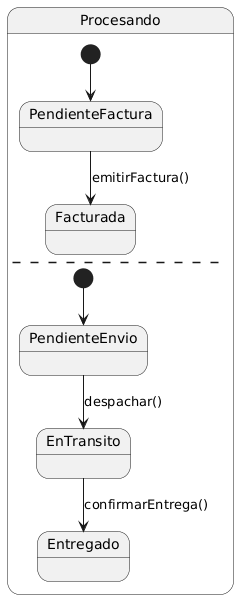

In [16]:
# Diagrama PlantUML
plantuml_code = '''@startuml
state Procesando {
  ' Región de facturación
  [*] --> PendienteFactura
  PendienteFactura --> Facturada : emitirFactura()
  --
  ' Región de envío
  [*] --> PendienteEnvio
  PendienteEnvio --> EnTransito : despachar()
  EnTransito --> Entregado : confirmarEntrega()
}
@enduml'''

render_plantuml(plantuml_code)


La guía (páginas 215-216) muestra ejemplos muy similares. Al entrar en `Procesando`, el objeto se encontrará simultáneamente en `PendienteFactura` y `PendienteEnvio`. Cada región evolucionará por separado según sus propios eventos. La salida del estado compuesto puede producirse cuando ambas regiones hayan alcanzado un estado final, o mediante una transición explícita desde el nivel superior que interrumpa ambas.

## 4.5. Puntos de elección, bifurcación y unión: el control del flujo

Para modelar lógica condicional y sincronización sin necesidad de crear estados artificiales, PlantUML soporta los pseudoestados mediante estereotipos. Estos se declaran como estados normales, pero con un estereotipo entre `<<` y `>>`. Los más relevantes son:

- `<<choice>>`: representa una decisión en la que se evalúan condiciones de guarda para enrutar a diferentes estados.
- `<<fork>>`: divide el flujo en varias ramas concurrentes que entran en regiones paralelas de un estado compuesto.
- `<<join>>`: sincroniza varias ramas concurrentes, esperando a que todas lleguen antes de continuar con una única transición.

Estos estereotipos se aplican directamente sobre cualquier estado con la sintaxis `state Nombre <<estereotipo>>`, y las transiciones se definen como flechas ordinarias. El ejemplo del punto de elección para elegir tipo de pago que vimos en la sección 2.6 ilustra perfectamente esta sintaxis.

La guía (páginas 217-218) muestra cómo combinar `<<fork>>` y `<<join>>` para entrar y salir de regiones concurrentes de manera explícita. Aunque muchos diagramas no requieren estos elementos, su disponibilidad en PlantUML nos permite modelar con total fidelidad situaciones complejas.

## 4.6. Personalización visual: adaptando el diagrama a la audiencia

Un mismo diagrama de estados puede presentarse a un comité de dirección, a un equipo de desarrollo o a un tester. Cada audiencia tiene necesidades diferentes de detalle y de impacto visual. PlantUML nos ofrece dos mecanismos principales para personalizar la apariencia: `skinparam` y las etiquetas `<style>`.

- **`skinparam`**: es la forma más directa de cambiar colores, fuentes y bordes. Podemos aplicarlo globalmente o a elementos específicos (`state`, `arrow`, etc.). Por ejemplo:


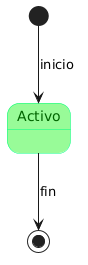

In [17]:
# Diagrama PlantUML
plantuml_code = '''@startuml
skinparam state {
  BackgroundColor PaleGreen
  BorderColor SpringGreen
  FontColor DarkGreen
}
[*] --> Activo : inicio
Activo --> [*] : fin
@enduml'''

render_plantuml(plantuml_code)


- **`<style>`**: más potente y flexible, permite definir estilos con selectores, similar a CSS. Se puede aplicar a clases, estereotipos y profundidades. Por ejemplo:


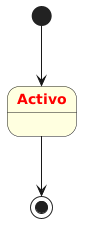

In [18]:
# Diagrama PlantUML
plantuml_code = '''@startuml
<style>
stateDiagram {
  .destacado {
    BackgroundColor LightYellow
    FontColor Red
    FontStyle bold
  }
}
</style>
state Activo <<destacado>>
[*] --> Activo
Activo --> [*]
@enduml'''

render_plantuml(plantuml_code)


La guía (páginas 226-228) dedica una sección completa a la personalización, incluyendo cómo cambiar el estilo de las líneas, las flechas y los textos. En la práctica de la gestión, suelo definir una paleta de estilos al inicio del proyecto y aplicarla consistentemente en todos los diagramas, asegurando que la documentación tenga una identidad visual unificada.

## 4.7. La notación como aliada del diseño riguroso

La notación PlantUML para diagramas de estados es, en esencia, un lenguaje de programación declarativo para el comportamiento temporal de las clases. Como tal, exige la misma disciplina que cualquier otro código: nombres claros, estructura lógica y documentación en forma de comentarios. 

Cuando enseñan a un equipo a usar esta notación, no solo están transmitiendo una sintaxis; están inculcando un método de pensamiento. Cada `state` que declaran, cada `-->` que dibujan, debe tener una razón de ser en el modelo de clases y en los casos de uso. La herramienta es flexible, pero el rigor debe ponerlo el diseñador.

Con este dominio de la notación, ya están en condiciones de modelar el ciclo de vida de cualquier entidad del sistema de manera profesional y mantenible.

# 5. Buenas prácticas y validación del diagrama de estados

## 5.1. Pertenencia a una clase: el estado no vaga solo

También podemos usar notas dentro del propio diagrama para dejar constancia. Pero lo esencial es que cualquier persona que abra ese archivo sepa, sin lugar a dudas, que está viendo el ciclo de vida de las instancias de una clase concreta del modelo estructural.

¿Por qué insisto tanto en esto? Porque la pertenencia a una clase es lo que da sentido a los estados y a los eventos. Los estados son valores que puede tomar un atributo de esa clase. Los eventos son métodos de esa clase o mensajes que recibe de otras. Las acciones son implementaciones que residen en la clase o en sus colaboradoras. Si no hay clase dueña, el diagrama de estados flota en el vacío y nadie se siente responsable de mantenerlo actualizado. En cambio, cuando el diagrama es propiedad de una clase, cualquier modificación en esa clase —un nuevo método, un cambio en un atributo— dispara automáticamente la pregunta: “¿Debo actualizar el diagrama de estados?”. Esa responsabilidad clara es lo que mantiene viva la documentación.

## 5.2. Coherencia total con los otros modelos UML

Un diagrama de estados no debería contener ninguna información que contradiga o que no esté respaldada por los otros artefactos del proyecto. Esta coherencia cruzada es, en mi experiencia, la prueba de fuego de un diseño bien hecho. Veamos las tres comprobaciones que realizo sistemáticamente:

**Primera comprobación: los eventos existen en los diagramas de secuencia.** Cada evento de transición —`confirmarPedido()`, `pagar()`, `cancelar()`— debe aparecer como un mensaje que el objeto recibe en al menos un diagrama de secuencia. Si el evento no aparece en ningún diagrama de secuencia, tenemos dos posibilidades: o bien hemos modelado un evento que nadie envía (un agujero funcional), o bien nos falta un diagrama de secuencia que documente esa interacción. En cualquier caso, hay que corregir la omisión. 

**Segunda comprobación: los estados son valores de atributos reales.** Cada estado del diagrama debe corresponderse con un valor que puede tomar el atributo `estado` de la clase (o el atributo que corresponda). Si en el diagrama de estados aparece un estado “Devuelto”, en la clase `Pedido` debe existir la posibilidad de que el atributo `estado` tome el valor `"devuelto"` (o `EstadoPedido.DEVUELTO` si usamos un enumerado). Esta correspondencia garantiza que el diagrama de estados es una especificación precisa del ciclo de vida y no una ilustración decorativa.

**Tercera comprobación: las transiciones están justificadas por los casos de uso.** Cada transición debería poder trazarse hasta un paso de un caso de uso. Si existe una transición de “Pagado” a “Enviado” con el evento `despachar()`, debería existir un caso de uso (por ejemplo, “Gestionar Envío”) en cuyo flujo básico o alternativo aparezca la acción de despachar un pedido. Si no hay tal caso de uso, el evento es espurio o hemos descubierto un requisito no documentado que debemos formalizar con los stakeholders.

Estas tres comprobaciones convierten el diagrama de estados en un nodo más de una red de modelos coherentes, en lugar de un gráfico aislado. Y lo que es más importante: cuando un cambio de requisitos obliga a modificar un caso de uso, el impacto se propaga de manera controlada al diagrama de secuencia correspondiente y, a través de él, al diagrama de estados de la entidad afectada. La documentación, entonces, no se rompe; evoluciona.

## 5.3. No modelar el mundo: el foco en el ciclo de vida del objeto

Uno de los antipatrones más dañinos que he visto es el del “diagrama de estados del sistema”. Se trata de un gráfico que pretende modelar el flujo global de la aplicación: “El usuario se loguea, luego va a la pantalla principal, después elige un producto, luego paga...”. Eso no es un diagrama de estados; es un bosquejo de navegación o, en el mejor de los casos, un diagrama de actividad. 

Un diagrama de estados **siempre** describe el comportamiento de **una clase**, no del sistema completo. Los estados son situaciones en las que se encuentra un objeto de esa clase, no fases del proceso global. Confundir ambos niveles de abstracción genera diagramas monumentales e inmantenibles que nadie sabe interpretar porque mezclan el ciclo de vida de múltiples objetos en una única vista.

La regla es simple: antes de dibujar un solo estado, pregúntense “¿de qué objeto estoy hablando?”. Si la respuesta involucra a más de una clase, están haciendo un diagrama de interacción o de actividad, no de estados. Vuelvan al modelo de clases, elijan una entidad, y cíñanse a ella. Su diagrama de estados tendrá entonces un tamaño manejable, un propósito claro y una audiencia específica: el desarrollador que tiene que implementar (o mantener) esa clase.

## 5.4. Validación lógica: cazando estados muertos y transiciones imposibles

Una de las aplicaciones más valiosas del diagrama de estados es la detección temprana de defectos de diseño. Un diagrama de estados es una máquina formal, y como tal, podemos razonar sobre ella. Yo acostumbro a hacer, junto con el equipo, una revisión sistemática en busca de tres tipos de problemas:

- **Estados muertos**: aquellos a los que el objeto nunca puede llegar porque no hay ninguna transición entrante (salvo el estado inicial, naturalmente). Si un estado no tiene flechas de entrada, es una isla inalcanzable.
- **Estados trampa**: aquellos de los que el objeto no puede salir porque no tienen transiciones de salida (salvo el estado final). Si el negocio dice que un pedido “Cancelado” es irreversible, está bien que no tenga salida; pero si existe un camino de vuelta que no se ha modelado, tenemos un bug funcional.
- **Transiciones imposibles**: aquellas que violan las reglas de negocio. Por ejemplo, una transición directa de “Entregado” a “Pendiente de Pago” debería disparar todas las alarmas. Revisar las transiciones una a una con el analista funcional es una de las actividades más productivas que pueden hacerse.

Para esta validación, PlantUML es un aliado excelente, porque el simple hecho de ver el diagrama generado permite detectar visualmente estados aislados o transiciones que cruzan todo el gráfico de manera extraña. Pero no se fíen solo de sus ojos; razonen sobre cada transición con la especificación textual en la mano.

## 5.5. Cierre: el diagrama de estados como brújula del diseño

Llegamos al final de este bloque sobre modelado de estados. Quiero que se lleven una idea central: el diagrama de estados es, ante todo, una herramienta de comunicación y de precisión. Cuando está bien construido, comunica de un vistazo lo que tardaríamos párrafos en explicar. Cuando está mal construido, confunde más que aclara y, peor aún, miente sobre el comportamiento del sistema.

A lo largo de estos temas, hemos visto que un diagrama de estados no se improvisa. Requiere identificar la clase adecuada, rastrear los eventos en los diagramas de secuencia, definir estados que reflejen valores de atributos y validar la coherencia con los casos de uso. Requiere, en suma, aplicar el mismo rigor que aplicamos al código fuente.

La recompensa es inmensa. Un sistema cuyas entidades críticas tienen diagramas de estados claros y actualizados es un sistema donde los desarrolladores saben exactamente qué tienen que implementar, los testers saben qué caminos deben probar, y los analistas pueden verificar que las reglas de negocio se respetan. Es un sistema, en definitiva, más robusto, más mantenible y más predecible.

Confíen en esta herramienta, pero no la conviertan en un fetiche. No necesitan un diagrama de estados para cada clase; solo para aquellas cuyo ciclo de vida sea lo bastante complejo como para merecerlo. Y cuando lo hagan, háganlo con propósito, con rigor y con la mirada puesta en el resto de los modelos que componen la arquitectura del software. Esa es la marca de un verdadero ingeniero.

---

# 6. Ejercicios de autoevaluación

## 6.1. Preguntas conceptuales

1. ¿Cuál es la diferencia fundamental entre un diagrama de estados y un diagrama de secuencia en términos del enfoque de modelado?

2. ¿Qué condiciones debe cumplir una clase para que merezca la pena modelar su diagrama de estados? Menciona al menos dos criterios.

3. Explica la diferencia entre `entry`, `exit` y `do` dentro de un estado. ¿En qué momento se ejecuta cada uno?

4. ¿Qué es un estado compuesto y qué ventaja ofrece frente a tener todos los estados en el mismo nivel?

5. ¿Cómo se representa la concurrencia en un diagrama de estados de PlantUML? Describe un ejemplo donde sea útil.

6. ¿Cuál es la diferencia entre un punto de elección (`<<choice>>`) y una bifurcación (`<<fork>>`)?

7. ¿Por qué es importante que cada evento en una transición sea trazable hasta un caso de uso o un diagrama de secuencia?

8. ¿Qué son los estados muertos y los estados trampa? ¿Cómo se detectan?

9. Si una clase tiene un atributo `estado` de tipo `String`, ¿qué relación debe existir entre los valores de ese atributo y los estados del diagrama?

10. ¿Cuándo conviene usar `skinparam` y cuándo conviene usar `<style>` en PlantUML para personalizar la apariencia?

## 6.2. Ejercicios prácticos

1. **Ciclo de vida de una Reserva de Hotel**: Modela en PlantUML el diagrama de estados de una clase `ReservaHotel`. Estados sugeridos: `Creada`, `Confirmada`, `Pagada`, `EstanciaActiva`, `Finalizada`, `Cancelada`. Incluye al menos una transición con condición de guarda y una con acción.

2. **Estados concurrentes en un Pedido**: Amplía el ejemplo del `Pedido` del tema para que el estado `Procesando` tenga tres regiones concurrentes: `Facturacion`, `Envio` y `Notificacion`. Cada región debe tener al menos dos estados.

3. **Submáquina de un estado compuesto**: Modela la clase `SolicitudVacaciones`. El estado `EnAprobacion` debe ser un estado compuesto que contenga los subestados `PendienteJefe`, `PendienteRRHH` (si son más de 10 días) y `Aprobada`.

4. **Detección de estados imposibles**: Dado el siguiente conjunto de reglas de negocio para un `PréstamoBiblioteca`, identifica qué transiciones son imposibles y corrígelas: `Solicitado → Prestado → Devuelto → Vencido → Sancionado`. Las reglas dicen: un préstamo vencido puede devolverse; un préstamo devuelto no puede vencerse; un préstamo sancionado puede pagar la multa y volver a estado normal.

5. **Punto de elección para métodos de pago**: Dado el estado `PendientePago` de un `Pedido`, modela un punto de elección que dirija a `PagadoTarjeta`, `PagadoPaypal` o `PagadoTransferencia` según el método de pago seleccionado.

6. **Validación cruzada**: Escribe una lista de verificación (checklist) de 5 puntos que usarías para validar que un diagrama de estados es coherente con el diagrama de clases y los diagramas de secuencia de un proyecto.

7. **De secuencia a estados**: Dado el siguiente conjunto de mensajes que recibe una clase `CuentaBancaria`: `abrir()`, `depositar()`, `retirar()`, `bloquear()`, `desbloquear()`, `cerrar()`. Define los estados y construye el diagrama de estados en PlantUML.

8. **Diagrama de estados con `entry` y `exit`**: Modela la clase `SesionUsuario` con los estados `Iniciada`, `Activa`, `Inactiva` y `Cerrada`. Asigna acciones `entry` y `exit` apropiadas (ej: al entrar en `Activa`, ejecutar `registrarInicioSesion`; al salir de `Activa`, ejecutar `guardarEstado`).

9. **Corrección de errores**: El siguiente diagrama contiene errores. Identifícalos y corrígelos:
   ```plantuml
   @startuml
   [*] --> Creado
   Creado --> Confirmado : pagar()
   Confirmado --> Cancelado : pagar()
   Cancelado --> Confirmado : deshacerCancelacion()
   Confirmado --> Enviado : despachar()
   Enviado --> Entregado : entregar()
   Entregado --> Creado : reiniciar()
   @enduml
   ```

10. **Proyecto completo**: Para la clase `ProyectoSoftware` de un sistema de gestión, define los estados por los que pasa (al menos 6), las transiciones con eventos, condiciones y acciones, e impleméntalo en PlantUML usando estados compuestos y al menos un punto de elección.
